In [151]:
import json
import pandas as pd
import numpy as np
import hvplot.pandas
import matplotlib.pyplot as plt

In [341]:
df_prm_int = pd.read_json('Scenario.codegeneration_10_0.2_code_eval_all.json')  # use code-trained
df_base = pd.read_json('BASE_10_0.2_eval_all.json')

In [422]:
len(df_base)

1055

In [382]:
correct_prm_int = df_prm_int[df_prm_int['pass@1'] > 0.0]
correct_base = df_base[df_base['pass@1'] > 0.0]

In [383]:
incorrect_prm_int = df_prm_int[df_prm_int['pass@1'] == 0.0]
incorrect_base = df_base[df_base['pass@1'] == 0.0]

In [384]:
print(f"Intuitor + PRM: {len(correct_prm_int)/len(df_base)}")

Intuitor + PRM: 0.16018957345971563


In [385]:
print(f"Base: {len(correct_base)/len(df_base)}")

Base: 0.1962085308056872


In [386]:
prob_dist_base = [correct_base['difficulty'].map(lambda x: x == diff).sum() for diff in ['easy', 'medium', 'hard']]
prob_dist_prm_int = [correct_prm_int['difficulty'].map(lambda x: x == diff).sum() for diff in ['easy', 'medium', 'hard']]

prob_dist_base, prob_dist_prm_int

([np.int64(164), np.int64(41), np.int64(2)],
 [np.int64(141), np.int64(25), np.int64(3)])

In [347]:
wrong_prob_dist_base = [incorrect_base['difficulty'].map(lambda x: x == diff).sum() for diff in ['easy', 'medium', 'hard']]
wrong_prob_dist_prm_int = [incorrect_prm_int['difficulty'].map(lambda x: x == diff).sum() for diff in ['easy', 'medium', 'hard']]

wrong_prob_dist_base, wrong_prob_dist_prm_int

([np.int64(158), np.int64(342), np.int64(348)],
 [np.int64(181), np.int64(358), np.int64(347)])

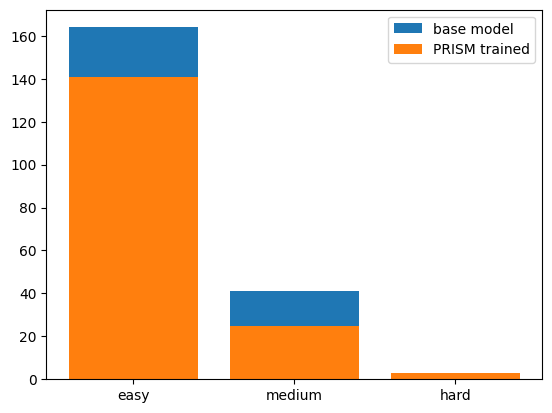

In [351]:
plt.bar(['easy', 'medium', 'hard'], prob_dist_base, label='base model')
plt.bar(['easy', 'medium', 'hard'], prob_dist_prm_int, label='PRISM trained')
plt.legend()

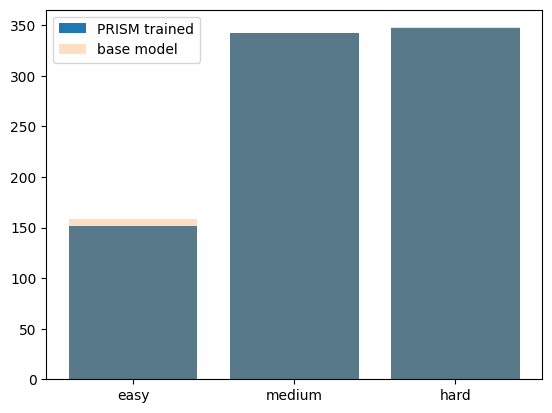

In [340]:
plt.bar(['easy', 'medium', 'hard'], wrong_prob_dist_prm_int, label='PRISM trained')
plt.bar(['easy', 'medium', 'hard'], wrong_prob_dist_base, alpha=0.25, label='base model')
plt.legend()

In [352]:
df_prm_int['pass@1'].mean(), df_base['pass@1'].mean()

(np.float64(0.1143127962085308), np.float64(0.13535545023696682))

In [363]:
base_got_wrong = [True if df_prm_int.iloc[i]['pass@1'] > 0.0 and
                     df_base.iloc[i]['pass@1'] == 0 else False for i in range(len(df_base))]

In [364]:
base_got_wrong = np.array(base_got_wrong)

In [391]:
df_base['pass@1'].hvplot.hist(color='blue', label='base', alpha=0.2)*df_prm_int['pass@1'].hvplot.hist(label='PRISM', alpha=0.5)

:Overlay
   .Histogram.I  :Histogram   [pass@1]   (Count)
   .Histogram.II :Histogram   [pass@1]   (Count)

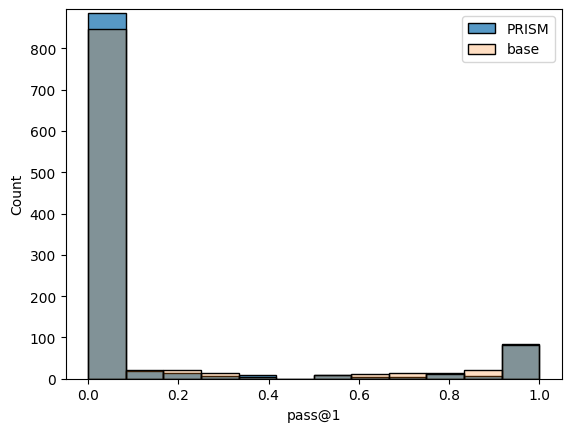

In [421]:
import seaborn as sns

plt.ylim([0, 895])
sns.histplot(df_prm_int['pass@1'], label='PRISM')
sns.histplot(df_base['pass@1'], label='base', alpha=0.25)
plt.legend()

(0.0, 895.0)

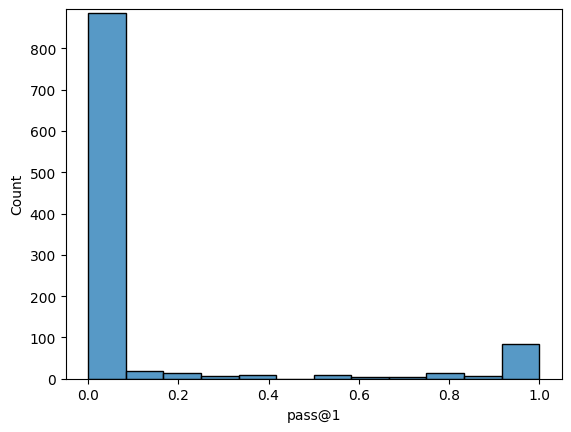

In [414]:
sns.histplot(df_prm_int['pass@1'], label='PRISM')
plt.ylim([0, 895])

In [429]:
df_base['pass@1'].describe()

count    1055.000000
mean        0.135355
std         0.312199
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: pass@1, dtype: float64

In [430]:
df_prm_int['pass@1'].describe()

count    1055.000000
mean        0.114313
std         0.296427
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: pass@1, dtype: float64

In [354]:
len(df_base[df_base['pass@1'] == 1.0])

82

In [355]:
len(df_prm_int[df_prm_int['pass@1'] == 1.0])

84

In [356]:
82/1055, 97/1055

(0.07772511848341232, 0.09194312796208531)

In [357]:
df_base['pass@1'].mean()

np.float64(0.13535545023696682)

In [358]:
df_prm_int['pass@1'].mean()

np.float64(0.1143127962085308)

In [365]:
base_wrong = df_base.iloc[base_got_wrong]
trained_right = df_prm_int.iloc[base_got_wrong]

In [369]:
base_wrong.iloc[0]

question_title                               max-pair-sum-in-an-array
question_content    You are given a 0-indexed integer array nums. ...
platform                                                     leetcode
question_id                                                      2902
contest_id                                         weekly-contest-358
contest_date                                      2023-08-13T00:00:00
starter_code        class Solution:\n    def maxSum(self, nums: Li...
difficulty                                                       easy
output_list         [class Solution:\n    def maxSum(self, nums: L...
code_list           [class Solution:\n    def maxSum(self, nums: L...
graded_list         [False, False, False, False, False, False, Fal...
pass@1                                                            0.0
metadata            [{"error": "IndexError('string index out of ra...
Name: 73, dtype: object

In [370]:
trained_right.iloc[0]

question_title                               max-pair-sum-in-an-array
question_content    You are given a 0-indexed integer array nums. ...
platform                                                     leetcode
question_id                                                      2902
contest_id                                         weekly-contest-358
contest_date                                      2023-08-13T00:00:00
starter_code        class Solution:\n    def maxSum(self, nums: Li...
difficulty                                                       easy
output_list         [class Solution:\n    def maxSum(self, nums: L...
code_list           [class Solution:\n    def maxSum(self, nums: L...
graded_list         [True, True, False, True, False, False, False,...
pass@1                                                            0.5
metadata            [{"execution time": 0.03791928291320801}, {"ex...
Name: 73, dtype: object

In [371]:
print(base_wrong.iloc[0]['output_list'][0])

class Solution:
    def maxSum(self, nums: List[int]) -> int:
        ans = -1
        for i in range(len(nums)):
            for j in range(i + 1, len(nums)):
                if max(int(str(nums[i])[0]), int(str(nums[j])[0])) == max(int(str(nums[i])[1]), int(str(nums[j])[1])):
                    ans = max(ans, nums[i] + nums[j])
        return ans




In [372]:
print(trained_right.iloc[0]['output_list'][0])

class Solution:
    def maxSum(self, nums: List[int]) -> int:
        ans = -1
        for i in range(len(nums)):
            for j in range(i + 1, len(nums)):
                if max(str(nums[i])) == max(str(nums[j])):
                    ans = max(ans, nums[i] + nums[j])
        return ans




In [379]:
base_wrong[base_wrong['difficulty'] == 'hard']

,question_title,question_content,platform,question_id,contest_id,contest_date,starter_code,difficulty,output_list,code_list,graded_list,pass@1,metadata
925,Rated Range,Takahashi plans to participate in N AtCoder co...,atcoder,abc389_f,abc389,2025-01-18T00:00:00,,hard,"[def minimum_moves(t, test_cases):\n for _ ...","[def minimum_moves(t, test_cases):\n for _ ...","[False, False, False, False, False, False, Fal...",0.0,"[{""error"": ""ValueError(\""invalid literal for i..."
988,Range Power Sum,"You are given positive integers N, K, and an i...",atcoder,abc399_f,abc399,2025-03-29T00:00:00,,hard,"[def minimum_moves(t, test_cases):\n for _ ...","[def minimum_moves(t, test_cases):\n for _ ...","[False, False, False, False, False, False, Fal...",0.0,"[{""error"": ""ValueError(\""invalid literal for i..."


In [381]:
trained_right.loc[988]

question_title                                        Range Power Sum
question_content    You are given positive integers N, K, and an i...
platform                                                      atcoder
question_id                                                  abc399_f
contest_id                                                     abc399
contest_date                                      2025-03-29T00:00:00
starter_code                                                         
difficulty                                                       hard
output_list         [def calculate_sum(n, k, a):\n    total_sum = ...
code_list           [def calculate_sum(n, k, a):\n    total_sum = ...
graded_list         [True, True, True, True, True, True, True, Tru...
pass@1                                                            1.0
metadata            [{"execution time": 0.669226884841919}, {"exec...
Name: 988, dtype: object